# Tutorial 03 — Gasificador 0D: Señales de BC (rampas, escalones, pulsos y control)

**Objetivo:** demostrar que `T_wall`, `Qwall` y otras BC del gasificador admiten
señales variables — `callable(t)` para perfiles temporales y `callable(t, snap)` para
retroalimentación de estado — sin cambiar nada en el RHS ni en el runner.

Todas las simulaciones son **0D, semibatch** (N=1, válvula ISA `Cv=0.5`, sin flujo de entrada).
El caso de referencia es T_wall constante a 1073.15 K (800 °C).

| Caso | BC modificada | Tipo de señal | Señal |
|------|--------------|---------------|-------|
| **Ref** | T_wall = 1073.15 K | constante | — |
| **3A** | T_wall | `ramp(t)` | 300 → 1073 K a 0.214 K/s |
| **3B** | T_wall | `step(t)` | 500 K → 1073 K a t=600 s |
| **3C** | Qwall | `pulse(t)` | 500 W en t∈[0, 600 s], 0 W después |
| **3D** | T_wall | `piecewise(t)` | 4 etapas: calentar → plateau → calentar → operar |
| **3E** | T_wall | `proportional(t, snap)` | control P → mantiene Ts_mean ≈ 700 K |

**Condición de salida:** válvula ISA-75.01 `Cv=0.5` — el gas ventea cuando P > P_out.

**Patrón de balances:**
```python
bal = check_balances(gasifier, params, verbose=False)
display_balances(bal)
```

In [5]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.io.fuels_reader                      import read_fueldb
from src.units.gasifier.config.boundary_c     import build_bc_config
from src.units.gasifier.config.thermal_bc     import build_thermal_bc_config
from src.units.gasifier.config.transport      import build_transport_config
from src.units.gasifier.config.gas_props      import build_gas_prop_config, GASIFIER_GAS_SPECIES
from src.units.gasifier.config.solid_props    import build_solid_prop_config
from src.units.gasifier.config.initial_c      import build_initial_c_config
from src.solvers.runner_gasifier              import run_step
from src.postprocessing.gasifier_balances     import check_balances, display_balances
from src.control.signals                      import ramp, step, pulse, piecewise
from src.control.controllers                  import proportional
from src.utils.signals                        import resolve

FUEL_PATH = os.path.join(ROOT, "materials", "fuels", "softwood_spruce.yaml")
GAS_DB    = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")

print("Imports OK")

Imports OK


In [6]:
# ── Combustible y geometría ───────────────────────────────────────────────────
fuel_config = read_fueldb(FUEL_PATH)
nc          = 9
N           = 1              # 0D — reactor perfectamente mezclado
species     = list(GASIFIER_GAS_SPECIES)

Di, Do  = 0.10, 0.114         # [m] diámetros interno/externo
e_wall  = (Do - Di) / 2       # [m] espesor de pared (7 mm, acero inox)
L       = 0.50                # [m] longitud
dz      = L / N
Ai      = 0.25 * np.pi * Di**2
Pi, Po  = np.pi * Di, np.pi * Do
epsi_r  = 0.60
dp0     = float(fuel_config["physical"]["dp_initial"])
rho_p   = float(fuel_config["physical"]["rho_particle"])
rho_char0 = fuel_config["pyrolysis_yields"]["char"] * rho_p * (1 - epsi_r)

# ── Condiciones de operación comunes ─────────────────────────────────────────
MC_WB   = 0.165    # [-]  contenido de humedad en base húmeda (16.5 %)
P_OUT   = 1.01325  # [bar]
T_END   = 3600.0   # [s]  duración
RTOL    = 1e-5
ATOL    = 1e-7
N_SEC   = 3        # puntos/s de salida

# ── Propiedades comunes ───────────────────────────────────────────────────────
prop_gas    = build_gas_prop_config(fuel_config=fuel_config, mode="polynomial", db_path=GAS_DB)
solid_cfg   = build_solid_prop_config(fuel_config)
gas_T_ref   = float(np.min(np.asarray(prop_gas["Tref"])))
MW_arr      = np.asarray(prop_gas["MW"])
trans_cfg   = build_transport_config(mode="constant", N=N, n_comp=nc, h_bed=80.0, h_wall=12.0)

# Salida: válvula ISA-75.01 con Cv=0.5 — gas ventea cuando P > P_out
bc_out = build_bc_config(n_comp=nc, P_out_bar=P_OUT, Cv=0.5)

# ── Condiciones iniciales comunes ─────────────────────────────────────────────
rho_bio_0 = rho_p * (1 - epsi_r)              # [kg/m³_bed]
rho_moi_0 = MC_WB / (1 - MC_WB) * rho_bio_0   # [kg/m³_bed]
y0 = np.zeros(nc); y0[species.index("N2")] = 1.0

init = build_initial_c_config(
    P_init=P_OUT, Tg_init=300.0, Ts_init=300.0, y_init=y0,
    rho_biomass_init=rho_bio_0, rho_char_init=1e-6, rho_moisture_init=rho_moi_0,
    n_comp=nc, N=N, prop_gas=prop_gas, epsi_r=epsi_r, gas_T_ref=gas_T_ref,
)
sv0 = init["sv0"]

# ── Parámetros base ───────────────────────────────────────────────────────────
params_base = {
    "n_comp":nc, "N":N, "dz":dz, "Ai":Ai, "Di":Di, "Pi":Pi, "Po":Po,
    "prop_gas":prop_gas, "MW":MW_arr, "gas_T_ref":gas_T_ref,
    "bc_config":bc_out, "trans_config":trans_cfg,
    "energy":True, "epsi_r":epsi_r, "dp0":dp0, "rho_char0":rho_char0,
    "fuel_config":fuel_config, "solid_config":solid_cfg, "species":species,
}

def make_params(tbc):
    """Devuelve params completo con el thermal_bc dado y caché limpio."""
    return {**params_base, "thermal_bc_config": tbc, "_cache": {}}

print(f"sv0.shape = {sv0.shape}  (17×N = {17*N})")
print(f"ρ_bio_0={rho_bio_0:.1f} kg/m³   ρ_moi_0={rho_moi_0:.1f} kg/m³")
print(f"Salida: válvula ISA Cv=0.5 — P_out={P_OUT:.5f} bar")
print(f"T_end={T_END:.0f} s | rtol={RTOL} | atol={ATOL} | n_sec={N_SEC}")

sv0.shape = (17,)  (17×N = 17)
ρ_bio_0=172.0 kg/m³   ρ_moi_0=34.0 kg/m³
Salida: válvula ISA Cv=0.5 — P_out=1.01325 bar
T_end=3600 s | rtol=1e-05 | atol=1e-07 | n_sec=3


In [7]:
# ── Caso referencia: T_wall = 1073.15 K constante ────────────────────────────
tbc_ref = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=1073.15,
    k_wall=16.5, rho_wall=7950.0, Cp_wall=510.0,
)
print("Simulando referencia (T_wall=1073.15 K constante, Cv=0.5)...")
t_ref, _, g_ref = run_step(
    sv0=sv0, t_max=T_END, params=make_params(tbc_ref),
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
print(f"✓  t={t_ref[-1]:.0f} s | Ts={g_ref._Ts_results[-1,0]-273.15:.0f} °C "
      f"| P_max={g_ref._P_results[:,0].max():.3f} bar"
      f"| ρ_bio={g_ref._rho_solid_results[-1,0,0]:.2f} kg/m³")

bal_ref = check_balances(g_ref, make_params(tbc_ref), verbose=False)
display_balances(bal_ref)

Simulando referencia (T_wall=1073.15 K constante, Cv=0.5)...


gasifier:   0%|          | 0.0/3600 s [00:00<?, ?s/s]

✓  t=3600 s | Ts=796 °C | P_max=1.058 bar| ρ_bio=0.00 kg/m³
── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-5.8115e-01,
Δm_sólido,-1.6593e+02,
Flujo_masa_neto,-1.6680e+02,
★ Cierre,+2.8575e-01,0.172 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


...

,Valor [J/m³],Nota
Término,,
ΔHg,+3.0596e+04,acumulación gas
Fh_conv_neto,-2.6037e+08,exacto
Q_gs (gas→sólido),+5.8553e+08,acum. ODE — exacto
Q_wall (pared→gas),+5.8813e+08,thermal_bc
Q_mt (sól→gas),+2.5781e+08,acum. ODE — exacto
★ Cierre_Hg,-4.9172e+03,-0.001 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+3.5012e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+5.8553e+08,acum. ODE — exacto
Q_rxn (exacto),-5.5140e+08,acum. ODE — exacto
★ Cierre_Hs,+8.8017e+05,0.150 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+3.5043e+07,acumulación total
Fh_conv_neto,-2.6037e+08,exacto
Q_wall,+5.8813e+08,thermal_bc
Q_rxn (exacto),-5.5140e+08,acum. ODE
Q_mt (exacto),+2.5781e+08,acum. ODE
★ Cierre global,+8.7526e+05,0.149 % ✓ OK


## 3A — Rampa de T_wall: 300 K → 1073 K en 3600 s

La pared parte de temperatura ambiente y sube linealmente hasta 800 °C a lo largo de toda
la simulación (`slope = (1073.15−300)/3600 ≈ 0.214 K/s`). La señal satura en 1073.15 K.

**Qué observar:** La pirólisis se retrasa respecto al caso constante — la pared tarda en
activar la cinética. La temperatura final del sólido debería ser similar en ambos casos.

Verificación T_wall_ramp(t):
  t=   0 s → 300.0 K
  t= 600 s → 428.9 K
  t=1800 s → 686.6 K
  t=3600 s → 1073.2 K

Simulando 3A (T_wall rampa 300→1073 K)...


gasifier:   0%|          | 0.0/3600 s [00:00<?, ?s/s]

✓  Ts=343 °C | ρ_bio=87.79 kg/m³


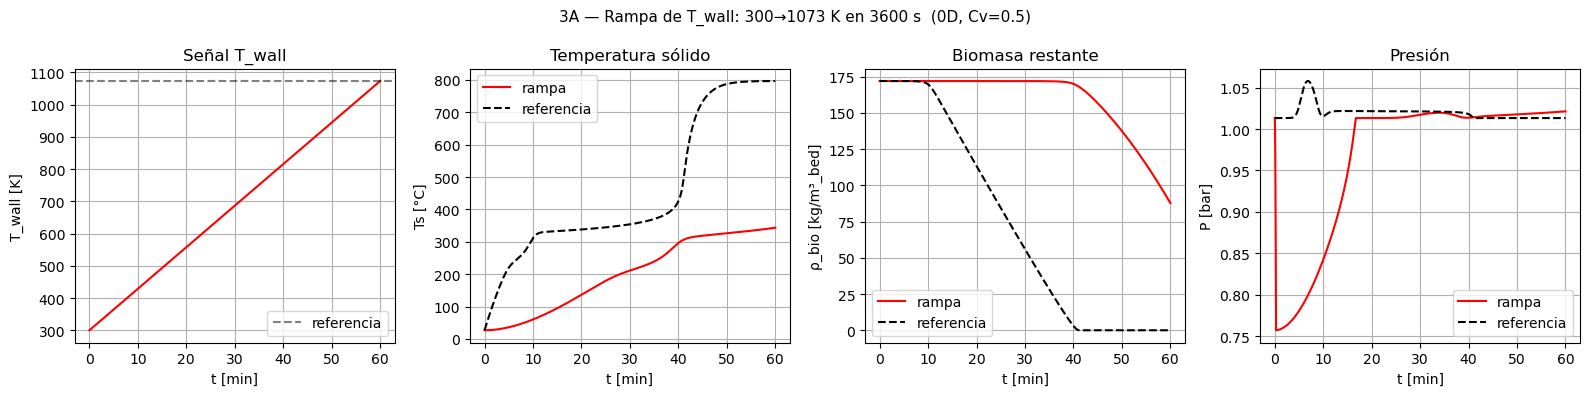

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-3.0300e-01,
Δm_sólido,-9.8495e+01,
Flujo_masa_neto,-9.8631e+01,
★ Cierre,-1.6714e-01,-0.170 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+1.451e+00 / +4.066e-02,-2.451e+02 / -6.865e+00,+2.465e+02 / +6.906e+00,+0.000e+00 / +0.000e+00
CO2,+1.397e+00 / +6.148e-02,-2.359e+02 / -1.038e+01,+2.373e+02 / +1.044e+01,+0.000e+00 / +0.000e+00
H2O,+3.137e+00 / +5.652e-02,-2.416e+03 / -4.353e+01,+2.420e+03 / +4.359e+01,+0.000e+00 / +0.000e+00
H2,+1.476e+00 / +2.975e-03,-2.492e+02 / -5.023e-01,+2.507e+02 / +5.053e-01,+0.000e+00 / +1.110e-16
O2,-1.100e-18 / -3.520e-20,+3.226e-16 / +1.032e-17,-3.237e-16 / -1.036e-17,+0.000e+00 / +0.000e+00
CH4,+4.945e-01 / +7.933e-03,-8.350e+01 / -1.339e+00,+8.399e+01 / +1.347e+00,+0.000e+00 / +2.220e-16
C2H4,+2.298e-01 / +6.445e-03,-3.879e+01 / -1.088e+00,+3.902e+01 / +1.095e+00,+0.000e+00 / +2.220e-16
tar,+3.600e+00 / +2.038e-01,-6.079e+02 / -3.441e+01,+6.115e+02 / +3.461e+01,+0.000e+00 / +0.000e+00
N2,-2.437e+01 / -6.828e-01,-1.833e+01 / -5.134e-01,-6.045e+00 / -1.694e-01,+0.000e+00 / +2.776e-17
── TOTAL ──,-1.259e+01 / -3.030e-01,-3.895e+03 / -9.863e+01,+3.883e+03 / +9.833e+01,+9.095e-13 / +0.000e+00



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+2.3827e+05,acumulación gas
Fh_conv_neto,-1.7312e+08,exacto
Q_gs (gas→sólido),+3.6253e+08,acum. ODE — exacto
Q_wall (pared→gas),+3.6341e+08,thermal_bc
Q_mt (sól→gas),+1.7253e+08,acum. ODE — exacto
★ Cierre_Hg,-5.3358e+04,-0.015 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+5.4679e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+3.6253e+08,acum. ODE — exacto
Q_rxn (exacto),-3.0786e+08,acum. ODE — exacto
★ Cierre_Hs,+6.5451e+03,0.002 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+5.4918e+07,acumulación total
Fh_conv_neto,-1.7312e+08,exacto
Q_wall,+3.6341e+08,thermal_bc
Q_rxn (exacto),-3.0786e+08,acum. ODE
Q_mt (exacto),+1.7253e+08,acum. ODE
★ Cierre global,-4.6813e+04,-0.013 % ✓ OK


In [8]:
T_wall_ramp = ramp(
    t_start=0.0, slope=(1073.15 - 300.0) / T_END,
    value_init=300.0, value_max=1073.15,
)
print("Verificación T_wall_ramp(t):")
for tc in [0, 600, 1800, 3600]:
    print(f"  t={tc:4d} s → {resolve(T_wall_ramp, float(tc)):.1f} K")

tbc_3a = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall_ramp, k_wall=16.5, rho_wall=7950.0, Cp_wall=510.0,
)
print("\nSimulando 3A (T_wall rampa 300→1073 K)...")
t_3a, _, g_3a = run_step(
    sv0=sv0, t_max=T_END, params=make_params(tbc_3a),
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
print(f"✓  Ts={g_3a._Ts_results[-1,0]-273.15:.0f} °C | ρ_bio={g_3a._rho_solid_results[-1,0,0]:.2f} kg/m³")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("3A — Rampa de T_wall: 300→1073 K en 3600 s  (0D, Cv=0.5)", fontsize=11)

axes[0].plot(t_3a/60, [resolve(T_wall_ramp, ti) for ti in t_3a], 'r-')
axes[0].axhline(1073.15, color='k', ls='--', alpha=0.5, label='referencia')
axes[0].set(xlabel="t [min]", ylabel="T_wall [K]", title="Señal T_wall")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_3a/60,  g_3a._Ts_results[:,0]-273.15, 'r-',  label='rampa')
axes[1].plot(t_ref/60, g_ref._Ts_results[:,0]-273.15, 'k--', label='referencia')
axes[1].set(xlabel="t [min]", ylabel="Ts [°C]", title="Temperatura sólido")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(t_3a/60,  g_3a._rho_solid_results[:,0,0], 'r-',  label='rampa')
axes[2].plot(t_ref/60, g_ref._rho_solid_results[:,0,0], 'k--', label='referencia')
axes[2].set(xlabel="t [min]", ylabel="ρ_bio [kg/m³_bed]", title="Biomasa restante")
axes[2].legend(); axes[2].grid(True)

axes[3].plot(t_3a/60,  g_3a._P_results[:,0], 'r-',  label='rampa')
axes[3].plot(t_ref/60, g_ref._P_results[:,0], 'k--', label='referencia')
axes[3].set(xlabel="t [min]", ylabel="P [bar]", title="Presión")
axes[3].legend(); axes[3].grid(True)

plt.tight_layout(); plt.show()

bal_3a = check_balances(g_3a, make_params(tbc_3a), verbose=False)
display_balances(bal_3a)

## 3B — Escalón de T_wall: 500 K → 1073 K a t = 600 s

La pared arranca en 500 K (activa el secado, no la pirólisis activa) y salta a 1073 K
a los 10 minutos. Simula un arranque con precalentamiento previo.

**Qué observar:** El secado ocurre en la fase de precalentamiento; la pirólisis
se activa bruscamente con el salto. La presión sube más tarde que en la referencia.

Simulando 3B (escalón T_wall: 500→1073 K a t=600 s)...


gasifier:   0%|          | 0.0/3600 s [00:00<?, ?s/s]

✓  Ts=792 °C | ρ_bio=0.00 kg/m³


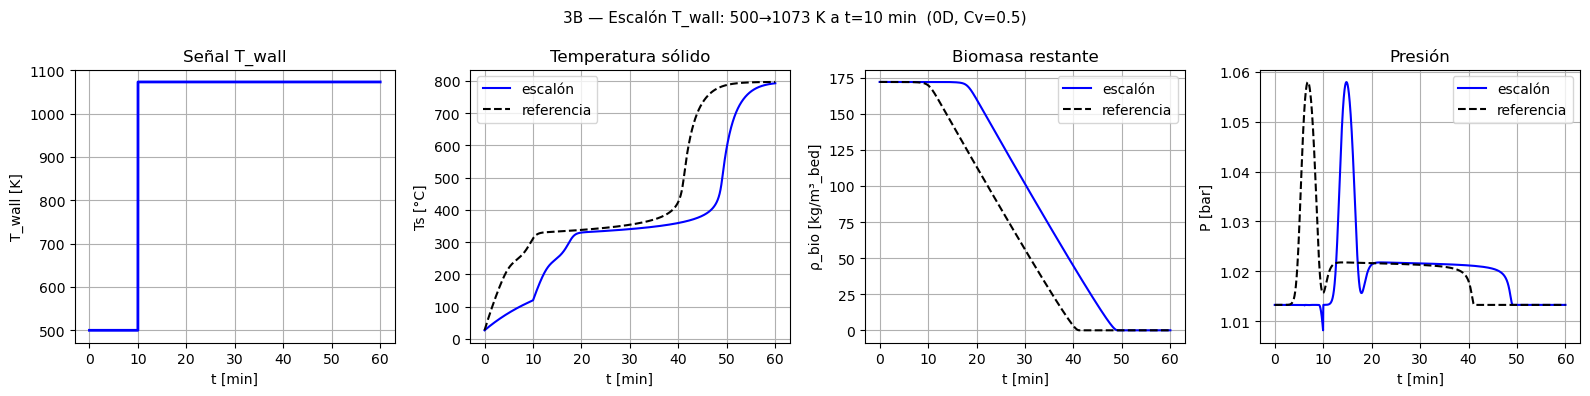

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-5.6794e-01,
Δm_sólido,-1.6583e+02,
Flujo_masa_neto,-1.6647e+02,
★ Cierre,+6.7555e-02,0.041 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+3.045e+00 / +8.530e-02,-5.087e+02 / -1.425e+01,+5.118e+02 / +1.434e+01,+0.000e+00 / -1.776e-15
CO2,+2.413e-03 / +1.062e-04,-4.840e+02 / -2.130e+01,+4.840e+02 / +2.130e+01,+0.000e+00 / -3.553e-15
H2O,+2.116e-01 / +3.811e-03,-2.974e+03 / -5.358e+01,+2.974e+03 / +5.359e+01,+0.000e+00 / +0.000e+00
H2,+3.222e+00 / +6.496e-03,-5.167e+02 / -1.042e+00,+5.199e+02 / +1.048e+00,+0.000e+00 / +0.000e+00
O2,-1.290e-14 / -4.128e-16,+2.650e-14 / +8.480e-16,-3.940e-14 / -1.261e-15,+0.000e+00 / +0.000e+00
CH4,+4.336e-02 / +6.955e-04,-1.715e+02 / -2.752e+00,+1.716e+02 / +2.752e+00,+0.000e+00 / +0.000e+00
C2H4,+2.014e-02 / +5.651e-04,-7.970e+01 / -2.236e+00,+7.972e+01 / +2.236e+00,+0.000e+00 / +4.441e-16
tar,+3.157e-01 / +1.787e-02,-1.249e+03 / -7.068e+01,+1.249e+03 / +7.070e+01,+0.000e+00 / +0.000e+00
N2,-2.437e+01 / -6.828e-01,-2.222e+01 / -6.224e-01,-2.156e+00 / -6.039e-02,+0.000e+00 / +0.000e+00
── TOTAL ──,-1.751e+01 / -5.679e-01,-6.006e+03 / -1.665e+02,+5.988e+03 / +1.659e+02,+0.000e+00 / -5.684e-14



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+4.8266e+04,acumulación gas
Fh_conv_neto,-2.5969e+08,exacto
Q_gs (gas→sólido),+5.8447e+08,acum. ODE — exacto
Q_wall (pared→gas),+5.8710e+08,thermal_bc
Q_mt (sól→gas),+2.5718e+08,acum. ODE — exacto
★ Cierre_Hg,-7.2473e+04,-0.012 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+3.4826e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+5.8447e+08,acum. ODE — exacto
Q_rxn (exacto),-5.5002e+08,acum. ODE — exacto
★ Cierre_Hs,+3.7897e+05,0.065 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+3.4874e+07,acumulación total
Fh_conv_neto,-2.5969e+08,exacto
Q_wall,+5.8710e+08,thermal_bc
Q_rxn (exacto),-5.5002e+08,acum. ODE
Q_mt (exacto),+2.5718e+08,acum. ODE
★ Cierre global,+3.0650e+05,0.052 % ✓ OK


In [9]:
T_wall_step = step(t_step=600.0, value_before=500.0, value_after=1073.15)

tbc_3b = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall_step, k_wall=16.5, rho_wall=7950.0, Cp_wall=510.0,
)
print("Simulando 3B (escalón T_wall: 500→1073 K a t=600 s)...")
t_3b, _, g_3b = run_step(
    sv0=sv0, t_max=T_END, params=make_params(tbc_3b),
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
print(f"✓  Ts={g_3b._Ts_results[-1,0]-273.15:.0f} °C | ρ_bio={g_3b._rho_solid_results[-1,0,0]:.2f} kg/m³")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("3B — Escalón T_wall: 500→1073 K a t=10 min  (0D, Cv=0.5)", fontsize=11)

axes[0].plot(t_3b/60, [resolve(T_wall_step, ti) for ti in t_3b], 'b-', lw=2)
axes[0].set(xlabel="t [min]", ylabel="T_wall [K]", title="Señal T_wall"); axes[0].grid(True)

axes[1].plot(t_3b/60,  g_3b._Ts_results[:,0]-273.15, 'b-',  label='escalón')
axes[1].plot(t_ref/60, g_ref._Ts_results[:,0]-273.15, 'k--', label='referencia')
axes[1].set(xlabel="t [min]", ylabel="Ts [°C]", title="Temperatura sólido")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(t_3b/60,  g_3b._rho_solid_results[:,0,0], 'b-',  label='escalón')
axes[2].plot(t_ref/60, g_ref._rho_solid_results[:,0,0], 'k--', label='referencia')
axes[2].set(xlabel="t [min]", ylabel="ρ_bio [kg/m³_bed]", title="Biomasa restante")
axes[2].legend(); axes[2].grid(True)

axes[3].plot(t_3b/60,  g_3b._P_results[:,0], 'b-',  label='escalón')
axes[3].plot(t_ref/60, g_ref._P_results[:,0], 'k--', label='referencia')
axes[3].set(xlabel="t [min]", ylabel="P [bar]", title="Presión")
axes[3].legend(); axes[3].grid(True)

plt.tight_layout(); plt.show()

bal_3b = check_balances(g_3b, make_params(tbc_3b), verbose=False)
display_balances(bal_3b)

## 3C — Pulso de Qwall: 500 W durante los primeros 10 min

El modo `heatfluxwall` prescribe la potencia total entregada al reactor. Con
`Qwall=pulse(...)` el calor se inyecta solo en t∈[0, 600 s]; después el sistema es adiabático.

**Qué observar:** ¿Es suficiente la energía inyectada (300 kJ) para pirolizar la carga?
Si la temperatura no supera el umbral cinético, la biomasa queda sin convertir.

Simulando 3C (pulso Qwall: 500 W durante 600 s)...


gasifier:   0%|          | 0.0/3600 s [00:00<?, ?s/s]

✓  Ts=146 °C | ρ_bio=171.99 kg/m³


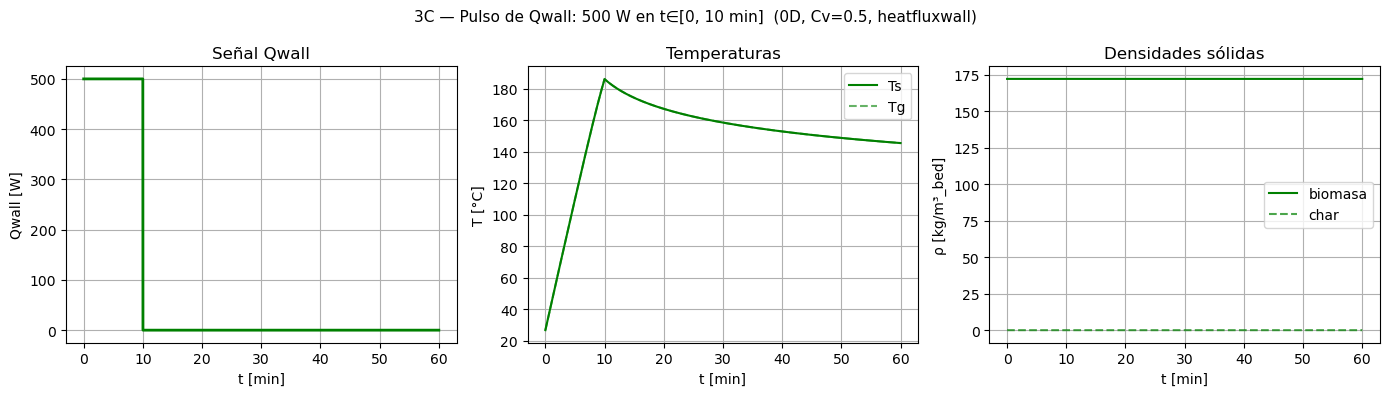

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-3.6807e-01,
Δm_sólido,-1.2998e+01,
Flujo_masa_neto,-1.3341e+01,
★ Cierre,-2.4837e-02,-0.191 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+6.698e-04 / +1.876e-05,-3.913e-02 / -1.096e-03,+3.980e-02 / +1.115e-03,+0.000e+00 / +0.000e+00
CO2,+6.447e-04 / +2.837e-05,-3.766e-02 / -1.658e-03,+3.831e-02 / +1.686e-03,+0.000e+00 / +0.000e+00
H2O,+1.746e+01 / +3.146e-01,-7.035e+02 / -1.267e+01,+7.210e+02 / +1.299e+01,+0.000e+00 / -1.776e-15
H2,+6.810e-04 / +1.373e-06,-3.979e-02 / -8.020e-05,+4.047e-02 / +8.158e-05,+0.000e+00 / +0.000e+00
O2,-2.377e-18 / -7.605e-20,+4.614e-17 / +1.476e-18,-4.852e-17 / -1.552e-18,+0.000e+00 / +0.000e+00
CH4,+2.282e-04 / +3.661e-06,-1.333e-02 / -2.139e-04,+1.356e-02 / +2.175e-04,+0.000e+00 / +0.000e+00
C2H4,+1.060e-04 / +2.974e-06,-6.194e-03 / -1.738e-04,+6.300e-03 / +1.767e-04,+0.000e+00 / +0.000e+00
tar,+1.661e-03 / +9.404e-05,-9.707e-02 / -5.494e-03,+9.873e-02 / +5.588e-03,+0.000e+00 / -8.674e-19
N2,-2.437e+01 / -6.828e-01,-2.351e+01 / -6.585e-01,-8.663e-01 / -2.427e-02,+0.000e+00 / +1.388e-17
── TOTAL ──,-6.908e+00 / -3.681e-01,-7.273e+02 / -1.334e+01,+7.203e+02 / +1.297e+01,+0.000e+00 / -1.776e-15



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+6.5706e+05,acumulación gas
Fh_conv_neto,-3.5839e+07,exacto
Q_gs (gas→sólido),+7.6326e+07,acum. ODE — exacto
Q_wall (pared→gas),+7.6373e+07,thermal_bc
Q_mt (sól→gas),+3.6437e+07,acum. ODE — exacto
★ Cierre_Hg,+1.1613e+04,0.015 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+4.6937e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+7.6326e+07,acum. ODE — exacto
Q_rxn (exacto),-2.9389e+07,acum. ODE — exacto
★ Cierre_Hs,+2.1789e+02,0.000 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+4.7594e+07,acumulación total
Fh_conv_neto,-3.5839e+07,exacto
Q_wall,+7.6373e+07,thermal_bc
Q_rxn (exacto),-2.9389e+07,acum. ODE
Q_mt (exacto),+3.6437e+07,acum. ODE
★ Cierre global,+1.1831e+04,0.015 % ✓ OK


In [10]:
Q_pulse = pulse(t_start=0.0, t_end=600.0, value_on=500.0, value_off=0.0)

tbc_3c = build_thermal_bc_config(
    mode="heatfluxwall", Di=Di, Do=Do, e_wall=e_wall,
    Qwall=Q_pulse, k_wall=16.5, rho_wall=7950.0, Cp_wall=510.0,
)
print("Simulando 3C (pulso Qwall: 500 W durante 600 s)...")
t_3c, _, g_3c = run_step(
    sv0=sv0, t_max=T_END, params=make_params(tbc_3c),
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
print(f"✓  Ts={g_3c._Ts_results[-1,0]-273.15:.0f} °C | ρ_bio={g_3c._rho_solid_results[-1,0,0]:.2f} kg/m³")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("3C — Pulso de Qwall: 500 W en t∈[0, 10 min]  (0D, Cv=0.5, heatfluxwall)", fontsize=11)

axes[0].plot(t_3c/60, [resolve(Q_pulse, ti) for ti in t_3c], 'g-', lw=2)
axes[0].set(xlabel="t [min]", ylabel="Qwall [W]", title="Señal Qwall"); axes[0].grid(True)

axes[1].plot(t_3c/60, g_3c._Ts_results[:,0]-273.15, 'g-',  label='Ts')
axes[1].plot(t_3c/60, g_3c._Tg_results[:,0]-273.15, 'g--', alpha=0.6, label='Tg')
axes[1].set(xlabel="t [min]", ylabel="T [°C]", title="Temperaturas")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(t_3c/60, g_3c._rho_solid_results[:,0,0], 'g-',  label='biomasa')
axes[2].plot(t_3c/60, g_3c._rho_solid_results[:,1,0], 'g--', alpha=0.7, label='char')
axes[2].set(xlabel="t [min]", ylabel="ρ [kg/m³_bed]", title="Densidades sólidas")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout(); plt.show()

bal_3c = check_balances(g_3c, make_params(tbc_3c), verbose=False)
display_balances(bal_3c)

## 3D — Piecewise: protocolo de calentamiento por etapas

Perfil de T_wall con 4 etapas definidas mediante `piecewise`:

| Etapa | t [min] | T_wall | Propósito |
|-------|---------|--------|-----------|
| 1 | 0–10 | 300→700 K | Calentamiento inicial / secado |
| 2 | 10–30 | 700 K | Plateau: secado completo |
| 3 | 30–40 | 700→1073 K | Calentamiento hacia pirólisis |
| 4 | 40–60 | 1073 K | Pirólisis a plena temperatura |

Simulando 3D (piecewise T_wall: 4 etapas)...


gasifier:   0%|          | 0.0/3600 s [00:00<?, ?s/s]

✓  Ts=374 °C | ρ_bio=24.14 kg/m³


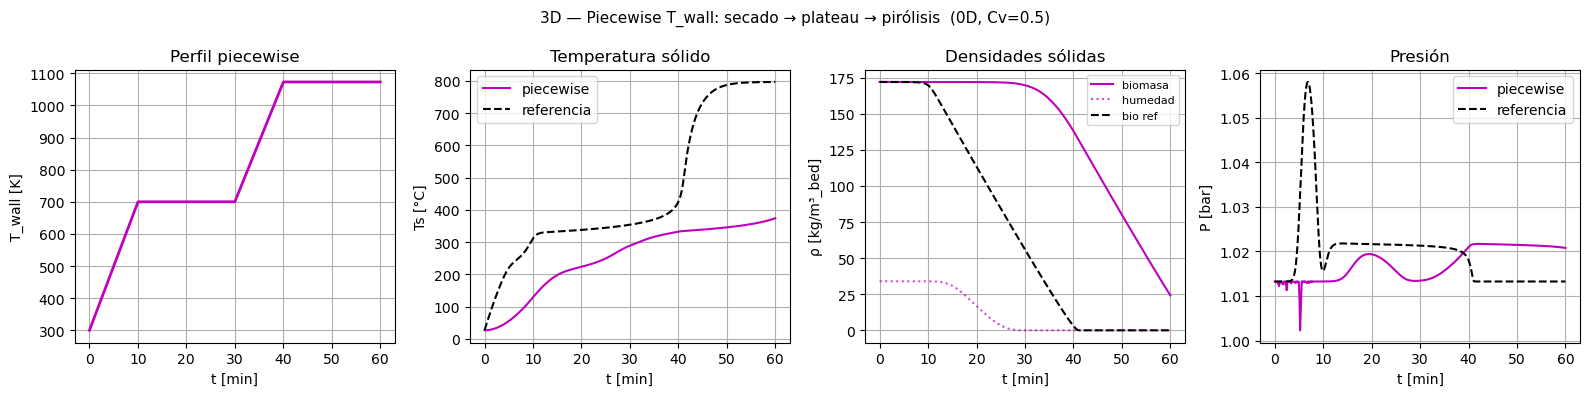

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-3.2154e-01,
Δm_sólido,-1.4725e+02,
Flujo_masa_neto,-1.4748e+02,
★ Cierre,-8.8769e-02,-0.060 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+1.381e+00 / +3.867e-02,-4.315e+02 / -1.209e+01,+4.329e+02 / +1.213e+01,+0.000e+00 / +0.000e+00
CO2,+1.329e+00 / +5.848e-02,-4.153e+02 / -1.828e+01,+4.166e+02 / +1.834e+01,+0.000e+00 / +0.000e+00
H2O,+2.984e+00 / +5.376e-02,-2.819e+03 / -5.079e+01,+2.822e+03 / +5.085e+01,+0.000e+00 / +7.105e-15
H2,+1.404e+00 / +2.830e-03,-4.387e+02 / -8.844e-01,+4.401e+02 / +8.872e-01,+0.000e+00 / +0.000e+00
O2,-8.796e-19 / -2.815e-20,+3.570e-16 / +1.142e-17,-3.579e-16 / -1.145e-17,+0.000e+00 / +0.000e+00
CH4,+4.703e-01 / +7.546e-03,-1.470e+02 / -2.358e+00,+1.475e+02 / +2.366e+00,+0.000e+00 / +0.000e+00
C2H4,+2.185e-01 / +6.131e-03,-6.830e+01 / -1.916e+00,+6.852e+01 / +1.922e+00,+0.000e+00 / +0.000e+00
tar,+3.424e+00 / +1.938e-01,-1.070e+03 / -6.058e+01,+1.074e+03 / +6.077e+01,+0.000e+00 / -7.105e-15
N2,-2.437e+01 / -6.828e-01,-2.105e+01 / -5.896e-01,-3.327e+00 / -9.320e-02,+0.000e+00 / -8.327e-17
── TOTAL ──,-1.316e+01 / -3.215e-01,-5.412e+03 / -1.475e+02,+5.398e+03 / +1.472e+02,-9.095e-13 / +5.684e-14



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+2.3855e+05,acumulación gas
Fh_conv_neto,-2.3264e+08,exacto
Q_gs (gas→sólido),+5.0394e+08,acum. ODE — exacto
Q_wall (pared→gas),+5.0584e+08,thermal_bc
Q_mt (sól→gas),+2.3102e+08,acum. ODE — exacto
★ Cierre_Hg,-3.8287e+04,-0.008 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+2.1467e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+5.0394e+08,acum. ODE — exacto
Q_rxn (exacto),-4.8248e+08,acum. ODE — exacto
★ Cierre_Hs,+1.2488e+04,0.002 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+2.1706e+07,acumulación total
Fh_conv_neto,-2.3264e+08,exacto
Q_wall,+5.0584e+08,thermal_bc
Q_rxn (exacto),-4.8248e+08,acum. ODE
Q_mt (exacto),+2.3102e+08,acum. ODE
★ Cierre global,-2.5799e+04,-0.005 % ✓ OK


In [11]:
T_wall_pw = piecewise(
    t_breakpoints=[0,    600,   1800,  2400,   3600],
    values=        [300,  700,   700,   1073.15, 1073.15],
)

tbc_3d = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall_pw, k_wall=16.5, rho_wall=7950.0, Cp_wall=510.0,
)
print("Simulando 3D (piecewise T_wall: 4 etapas)...")
t_3d, _, g_3d = run_step(
    sv0=sv0, t_max=T_END, params=make_params(tbc_3d),
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
print(f"✓  Ts={g_3d._Ts_results[-1,0]-273.15:.0f} °C | ρ_bio={g_3d._rho_solid_results[-1,0,0]:.2f} kg/m³")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("3D — Piecewise T_wall: secado → plateau → pirólisis  (0D, Cv=0.5)", fontsize=11)

axes[0].plot(t_3d/60, [resolve(T_wall_pw, ti) for ti in t_3d], 'm-', lw=2)
axes[0].set(xlabel="t [min]", ylabel="T_wall [K]", title="Perfil piecewise"); axes[0].grid(True)

axes[1].plot(t_3d/60,  g_3d._Ts_results[:,0]-273.15, 'm-',  label='piecewise')
axes[1].plot(t_ref/60, g_ref._Ts_results[:,0]-273.15, 'k--', label='referencia')
axes[1].set(xlabel="t [min]", ylabel="Ts [°C]", title="Temperatura sólido")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(t_3d/60, g_3d._rho_solid_results[:,0,0], 'm-',  label='biomasa')
axes[2].plot(t_3d/60, g_3d._rho_solid_results[:,2,0], 'm:',  alpha=0.7, label='humedad')
axes[2].plot(t_ref/60, g_ref._rho_solid_results[:,0,0], 'k--', label='bio ref')
axes[2].set(xlabel="t [min]", ylabel="ρ [kg/m³_bed]", title="Densidades sólidas")
axes[2].legend(fontsize=8); axes[2].grid(True)

axes[3].plot(t_3d/60,  g_3d._P_results[:,0], 'm-',  label='piecewise')
axes[3].plot(t_ref/60, g_ref._P_results[:,0], 'k--', label='referencia')
axes[3].set(xlabel="t [min]", ylabel="P [bar]", title="Presión")
axes[3].legend(); axes[3].grid(True)

plt.tight_layout(); plt.show()

bal_3d = check_balances(g_3d, make_params(tbc_3d), verbose=False)
display_balances(bal_3d)

## 3E — Control proporcional: T_wall ajustada para mantener Ts_mean ≈ 700 K

Un controlador P ajusta T_wall en **cada llamada al RHS** (incluida la estimación del
Jacobiano BDF) usando el snap interno del RHS — `Ts_mean` del sólido en ese instante.

**Controlador:** `T_wall = clamp(800 + 3×(700−Ts_mean), 300, 1200)` [K]  
**Qué observar:** Ts se regula cerca del SP; el controlador P tiene error en estado
estacionario (no hay integral). La pirólisis es más lenta que con T_wall=1073 K.

Simulando 3E (ctrl P T_wall, SP_Ts=700.0 K)...


gasifier:   0%|          | 0.0/3600 s [00:00<?, ?s/s]

✓  Ts=452 °C | ρ_bio=0.00 kg/m³


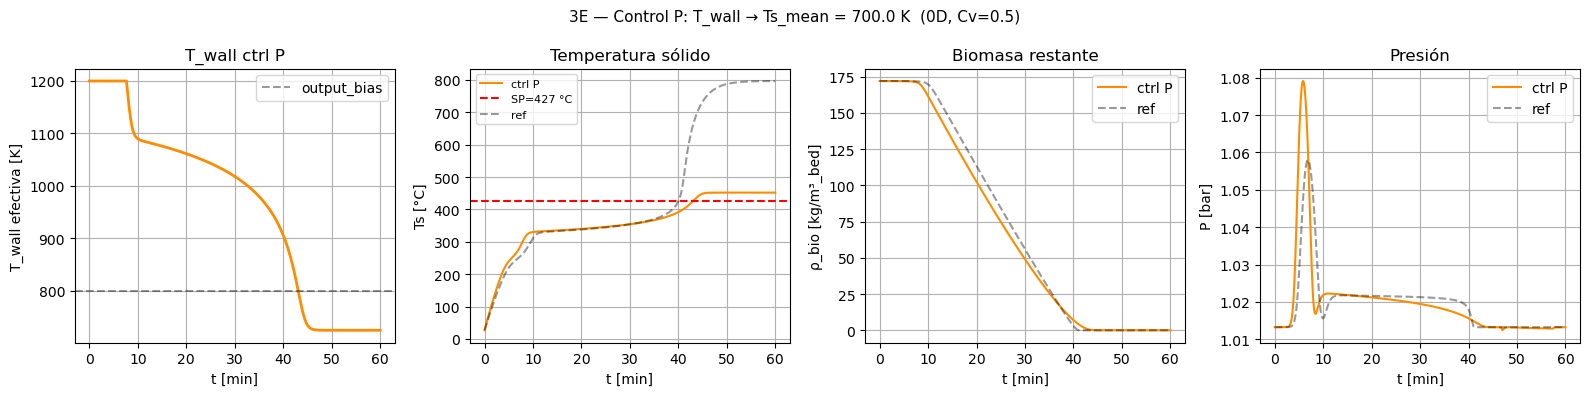

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-3.5965e-01,
Δm_sólido,-1.6574e+02,
Flujo_masa_neto,-1.6610e+02,
★ Cierre,+2.3962e-03,0.001 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+1.229e+00 / +3.442e-02,-5.023e+02 / -1.407e+01,+5.035e+02 / +1.410e+01,+0.000e+00 / +0.000e+00
CO2,+1.179e+00 / +5.191e-02,-4.834e+02 / -2.128e+01,+4.846e+02 / +2.133e+01,+0.000e+00 / +0.000e+00
H2O,+2.775e+00 / +5.000e-02,-2.972e+03 / -5.355e+01,+2.975e+03 / +5.360e+01,+0.000e+00 / -7.105e-15
H2,+1.248e+00 / +2.517e-03,-5.107e+02 / -1.029e+00,+5.119e+02 / +1.032e+00,+0.000e+00 / +0.000e+00
O2,-2.343e-24 / -7.497e-26,+7.292e-19 / +2.333e-20,-7.292e-19 / -2.333e-20,+0.000e+00 / -3.009e-36
CH4,+4.177e-01 / +6.701e-03,-1.711e+02 / -2.745e+00,+1.715e+02 / +2.752e+00,+0.000e+00 / +0.000e+00
C2H4,+1.941e-01 / +5.445e-03,-7.951e+01 / -2.231e+00,+7.970e+01 / +2.236e+00,+0.000e+00 / +0.000e+00
tar,+3.041e+00 / +1.721e-01,-1.246e+03 / -7.052e+01,+1.249e+03 / +7.069e+01,+0.000e+00 / +0.000e+00
N2,-2.437e+01 / -6.828e-01,-2.435e+01 / -6.823e-01,-1.844e-02 / -5.166e-04,+0.000e+00 / -2.082e-17
── TOTAL ──,-1.429e+01 / -3.596e-01,-5.990e+03 / -1.661e+02,+5.975e+03 / +1.657e+02,-1.819e-12 / +0.000e+00



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+2.3981e+05,acumulación gas
Fh_conv_neto,-2.5833e+08,exacto
Q_gs (gas→sólido),+5.5986e+08,acum. ODE — exacto
Q_wall (pared→gas),+5.6206e+08,thermal_bc
Q_mt (sól→gas),+2.5637e+08,acum. ODE — exacto
★ Cierre_Hg,-1.4582e+04,-0.003 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+1.1147e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+5.5986e+08,acum. ODE — exacto
Q_rxn (exacto),-5.4872e+08,acum. ODE — exacto
★ Cierre_Hs,+7.7991e+03,0.001 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+1.1387e+07,acumulación total
Fh_conv_neto,-2.5833e+08,exacto
Q_wall,+5.6206e+08,thermal_bc
Q_rxn (exacto),-5.4872e+08,acum. ODE
Q_mt (exacto),+2.5637e+08,acum. ODE
★ Cierre global,-6.7826e+03,-0.001 % ✓ OK


In [13]:
SP_Ts = 700.0   # [K]  setpoint de Ts_mean

ctrl_P = proportional(
    setpoint=SP_Ts, gain=3.0,
    channel_in=lambda snap: snap.get("Ts_mean", 300.0),
    output_bias=800.0, output_min=300.0, output_max=1200.0,
)
tbc_3e = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=ctrl_P,           # callable(t, snap) → float
    k_wall=16.5, rho_wall=7950.0, Cp_wall=510.0,
)

print(f"Simulando 3E (ctrl P T_wall, SP_Ts={SP_Ts} K)...")
t_3e, _, g_3e = run_step(
    sv0=sv0, t_max=T_END, params=make_params(tbc_3e),
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
print(f"✓  Ts={g_3e._Ts_results[-1,0]-273.15:.0f} °C | ρ_bio={g_3e._rho_solid_results[-1,0,0]:.2f} kg/m³")

# Reconstruir T_wall efectiva post-hoc: T_wall = clamp(800 + 3*(700 - Ts), 300, 1200)
Ts_hist    = g_3e._Ts_results[:,0]
T_wall_eff = np.clip(800.0 + 3.0 * (SP_Ts - Ts_hist), 300.0, 1200.0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"3E — Control P: T_wall → Ts_mean = {SP_Ts} K  (0D, Cv=0.5)", fontsize=11)

axes[0].plot(t_3e/60, T_wall_eff, color='darkorange', lw=2)
axes[0].axhline(800.0, color='k', ls='--', alpha=0.4, label='output_bias')
axes[0].set(xlabel="t [min]", ylabel="T_wall efectiva [K]", title="T_wall ctrl P")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_3e/60, Ts_hist-273.15, color='darkorange', label='ctrl P')
axes[1].axhline(SP_Ts-273.15, color='r', ls='--', label=f'SP={SP_Ts-273.15:.0f} °C')
axes[1].plot(t_ref/60, g_ref._Ts_results[:,0]-273.15, 'k--', alpha=0.4, label='ref')
axes[1].set(xlabel="t [min]", ylabel="Ts [°C]", title="Temperatura sólido")
axes[1].legend(fontsize=8); axes[1].grid(True)

axes[2].plot(t_3e/60, g_3e._rho_solid_results[:,0,0], color='darkorange', label='ctrl P')
axes[2].plot(t_ref/60, g_ref._rho_solid_results[:,0,0], 'k--', alpha=0.4, label='ref')
axes[2].set(xlabel="t [min]", ylabel="ρ_bio [kg/m³_bed]", title="Biomasa restante")
axes[2].legend(); axes[2].grid(True)

axes[3].plot(t_3e/60, g_3e._P_results[:,0], color='darkorange', label='ctrl P')
axes[3].plot(t_ref/60, g_ref._P_results[:,0], 'k--', alpha=0.4, label='ref')
axes[3].set(xlabel="t [min]", ylabel="P [bar]", title="Presión")
axes[3].legend(); axes[3].grid(True)

plt.tight_layout(); plt.show()

bal_3e = check_balances(g_3e, make_params(tbc_3e), verbose=False)
display_balances(bal_3e)

## Resumen comparativo — todos los casos

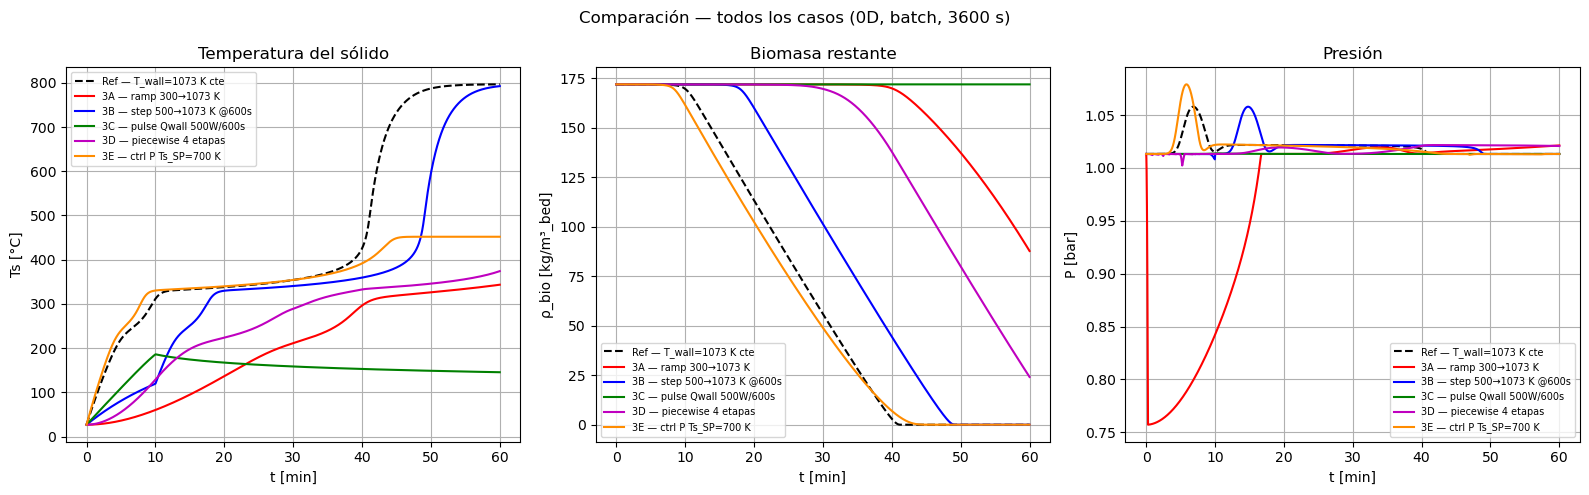

,Ts_fin [°C],P_max [bar],ρ_bio_fin [kg/m³],conv_bio [%]
caso,,,,
Ref — T_wall=1073 K cte,796.0,1.058,0.00,100.0
3A — ramp 300→1073 K,343.0,1.021,87.79,49.0
3B — step 500→1073 K @600s,792.0,1.058,0.00,100.0
3C — pulse Qwall 500W/600s,146.0,1.014,171.99,0.0
3D — piecewise 4 etapas,374.0,1.022,24.14,86.0
3E — ctrl P Ts_SP=700 K,452.0,1.079,0.00,100.0


In [14]:
casos = [
    ("Ref — T_wall=1073 K cte",    t_ref, g_ref, 'k',          '--'),
    ("3A — ramp 300→1073 K",       t_3a,  g_3a,  'r',          '-'),
    ("3B — step 500→1073 K @600s", t_3b,  g_3b,  'b',          '-'),
    ("3C — pulse Qwall 500W/600s",  t_3c,  g_3c,  'g',          '-'),
    ("3D — piecewise 4 etapas",    t_3d,  g_3d,  'm',          '-'),
    ("3E — ctrl P Ts_SP=700 K",    t_3e,  g_3e,  'darkorange', '-'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparación — todos los casos (0D, batch, 3600 s)", fontsize=12)
for lbl, t_, g_, col, ls in casos:
    axes[0].plot(t_/60, g_._Ts_results[:,0]-273.15,    color=col, ls=ls, lw=1.5, label=lbl)
    axes[1].plot(t_/60, g_._rho_solid_results[:,0,0],  color=col, ls=ls, lw=1.5, label=lbl)
    axes[2].plot(t_/60, g_._P_results[:,0],            color=col, ls=ls, lw=1.5, label=lbl)
axes[0].set(xlabel="t [min]", ylabel="Ts [°C]",          title="Temperatura del sólido")
axes[1].set(xlabel="t [min]", ylabel="ρ_bio [kg/m³_bed]",title="Biomasa restante")
axes[2].set(xlabel="t [min]", ylabel="P [bar]",           title="Presión")
for ax in axes:
    ax.legend(fontsize=7); ax.grid(True)
plt.tight_layout(); plt.show()

# Tabla de métricas finales
rows = []
for lbl, t_, g_, *_ in casos:
    bio0 = g_._rho_solid_results[0,0,0]
    biof = g_._rho_solid_results[-1,0,0]
    rows.append({
        "caso":              lbl,
        "Ts_fin [°C]":       round(float(g_._Ts_results[-1,0])-273.15, 0),
        "P_max [bar]":       round(float(g_._P_results[:,0].max()), 3),
        "ρ_bio_fin [kg/m³]": round(float(biof), 2),
        "conv_bio [%]":      round(100*(1-biof/bio0) if bio0>0 else 0, 1),
    })
display(pd.DataFrame(rows).set_index("caso"))

## Conclusiones

**Qué demuestra este test:**
- Los tres tipos de señal BC (`float`, `callable(t)`, `callable(t, snap)`) funcionan
  sin cambiar nada en el RHS ni en el runner. Los balances cierran en todos los casos.
- El solver BDF maneja correctamente señales discontinuas (escalón, pulso).
- El snap del RHS alimenta correctamente al controlador P: `Ts_mean` se actualiza
  en cada llamada al RHS durante la integración.

**Diferencias entre casos:**

| Caso | Señal | Efecto principal |
|------|-------|------------------|
| Ref  | cte 1073 K | Conversión rápida desde t=0 |
| 3A ramp | 300→1073 K/3600s | Retardo de pirólisis; misma Ts final |
| 3B step | 500→1073 K @10min | Secado en fase 1; pirólisis brusca con el salto |
| 3C pulse | 500W×10min | Energía insuficiente → conversión parcial |
| 3D piecewise | 4 etapas | Velocidad de conversión controlada por tramos |
| 3E ctrl P | Ts_mean→SP=700K | Ts regulada; pirólisis más lenta que referencia |

**Próximos pasos:**
- Control `onoff` de T_wall y comparación con ctrl P.
- Señales en `v_gas_in` para simular arranque/corte del agente gasificante.
- Subir a 1D (N=10) para ver respuesta espacial ante señales temporales.
- `tutorial_gasifier_04_0D_control.ipynb` — PID, barrido paramétrico, optimización.